# Studio Statistico: Cartesiano vs Polare

Confrontiamo sistematicamente le due trasformazioni su tutti i dataset disponibili con:
- Metriche multiple per valutazione completa
- Test statistici appaiati (paired t-test e Wilcoxon)
- Analisi della distribuzione delle differenze
- Valutazione della robustezza

In [40]:
import pandas as pd
from scipy import stats
from sklearn.metrics import silhouette_score
import warnings
import numpy as np
from sklearn.decomposition import PCA
from hdbscan import HDBSCAN

from utils.skeletonPATS import SkeletonPATS
from pats.utils import load_multiple_samples, get_speaker_intervals


warnings.filterwarnings('ignore')

def compute_clustering_metrics(poses: np.ndarray, min_cluster_size=20, min_samples=5):
    """
    Calcola metriche complete per valutare la qualità del clustering HDBSCAN
    
    Returns dict con:
    - persistence: somma delle persistenze dei cluster
    - noise_ratio: percentuale di punti classificati come rumore
    - avg_membership_prob: media delle probabilità di membership
    - n_clusters: numero di cluster trovati
    - silhouette: silhouette score sui punti non-rumore
    - cluster_sizes: lista delle dimensioni dei cluster
    """
    
    if len(poses) == 0:
        return None
    
    # Reshape e PCA
    data = np.array(poses)
    transformer = PCA(n_components=2)
    scaled = transformer.fit_transform(data.reshape(len(data), -1))
    
    # HDBSCAN con prediction_data=True per avere persistence e probabilities
    clusterer = HDBSCAN(
        min_cluster_size=min_cluster_size, 
        min_samples=min_samples, 
        prediction_data=True
    )
    labels = clusterer.fit_predict(scaled)
    
    # Metriche base
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_mask = labels == -1
    noise_ratio = noise_mask.sum() / len(labels)
    
    # Persistence: somma delle persistenze dei cluster
    # Maggiore = cluster più stabili e ben separati
    persistence = 0.0
    if hasattr(clusterer, 'cluster_persistence_'):
        persistence = clusterer.cluster_persistence_.sum()
    
    # Probabilità di membership
    # Maggiore = clustering più sicuro/deciso
    avg_membership_prob = 0.0
    if hasattr(clusterer, 'probabilities_'):
        avg_membership_prob = clusterer.probabilities_.mean()
    
    # Silhouette solo sui punti non-rumore
    silhouette = -1.0
    if n_clusters > 1 and (~noise_mask).sum() > n_clusters:
        try:
            non_noise_points = scaled[~noise_mask]
            non_noise_labels = labels[~noise_mask]
            silhouette = silhouette_score(non_noise_points, non_noise_labels)
        except:
            silhouette = -1.0
    
    # Dimensioni dei cluster
    cluster_sizes = []
    for cluster_id in range(n_clusters):
        size = (labels == cluster_id).sum()
        cluster_sizes.append(size)
    
    return {
        'persistence': persistence,
        'noise_ratio': noise_ratio,
        'avg_membership_prob': avg_membership_prob,
        'n_clusters': n_clusters,
        'silhouette': silhouette,
        'cluster_sizes': cluster_sizes,
        'total_points': len(labels)
    }

## Caricamento di tutti i dataset disponibili

In [41]:
# Carica tutti gli intervalli disponibili
speaker = "fallon"
split = "dev"

intervals = get_speaker_intervals(speaker, split=split)
print(f"Numero totale di dataset disponibili: {len(intervals)}")

# Per test rapido, usa un subset. Per analisi completa, usa tutti
# N_DATASETS = 20  # subset per test veloce
N_DATASETS = len(intervals)  # tutti i dataset

print(f"Useremo {N_DATASETS} dataset per l'analisi")

Numero totale di dataset disponibili: 202
Useremo 202 dataset per l'analisi


## Calcolo metriche per tutte le trasformazioni

Per ogni dataset:
1. Carica le pose
2. Calcola metriche con trasformazione cartesiana
3. Calcola metriche con trasformazione polare
4. Salva i risultati

In [42]:
from tqdm import tqdm

# Parametri HDBSCAN (stessi per entrambe le trasformazioni)
MIN_CLUSTER_SIZE = 20
MIN_SAMPLES = 5

results = []

for idx in tqdm(range(N_DATASETS), desc="Analisi dataset"):
    try:
        # Carica dataset
        clips = load_multiple_samples(
            speaker=speaker, 
            interval_ids=intervals[idx:idx+1]
        )
        
        # Estrai pose
        skeleton_poses = []
        for clip in clips:
            pose = clip['pose']
            pose[:, 0] = [0.0, 0.0]  # centra sul collo
            skeleton_poses.append(pose)
        
        skeleton_poses = np.concatenate(skeleton_poses, axis=0)
        
        # Salta dataset troppo piccoli
        if len(skeleton_poses) < MIN_CLUSTER_SIZE * 2:
            continue
        
        # Trasformazione polare
        polar_poses = SkeletonPATS.encode_as_polar(skeleton_poses)
        
        # Calcola metriche per cartesiano
        metrics_cartesian = compute_clustering_metrics(
            skeleton_poses, 
            min_cluster_size=MIN_CLUSTER_SIZE,
            min_samples=MIN_SAMPLES
        )
        
        # Calcola metriche per polare
        metrics_polar = compute_clustering_metrics(
            polar_poses,
            min_cluster_size=MIN_CLUSTER_SIZE,
            min_samples=MIN_SAMPLES
        )
        
        if metrics_cartesian is not None and metrics_polar is not None:
            results.append({
                'dataset_idx': idx,
                'n_frames': len(skeleton_poses),
                # Metriche cartesiano
                'cart_persistence': metrics_cartesian['persistence'],
                'cart_noise_ratio': metrics_cartesian['noise_ratio'],
                'cart_avg_prob': metrics_cartesian['avg_membership_prob'],
                'cart_n_clusters': metrics_cartesian['n_clusters'],
                'cart_silhouette': metrics_cartesian['silhouette'],
                # Metriche polare
                'polar_persistence': metrics_polar['persistence'],
                'polar_noise_ratio': metrics_polar['noise_ratio'],
                'polar_avg_prob': metrics_polar['avg_membership_prob'],
                'polar_n_clusters': metrics_polar['n_clusters'],
                'polar_silhouette': metrics_polar['silhouette'],
            })
    
    except Exception as e:
        print(f"Errore nel dataset {idx}: {e}")
        continue

# Converti in DataFrame
df_results = pd.DataFrame(results)
print(f"\nDataset analizzati con successo: {len(df_results)}")
print(f"\nPrime righe dei risultati:")
print(df_results.head())

Analisi dataset: 100%|██████████| 202/202 [01:52<00:00,  1.80it/s]


Dataset analizzati con successo: 202

Prime righe dei risultati:
   dataset_idx  n_frames  cart_persistence  cart_noise_ratio  cart_avg_prob  \
0            0       735          0.335046          0.127891       0.811736   
1            1       409          0.526369          0.004890       0.823869   
2            2       123          0.000000          1.000000       0.000000   
3            3       294          0.849685          0.010204       0.763423   
4            4       567          0.410708          0.315697       0.540365   

   cart_n_clusters  cart_silhouette  polar_persistence  polar_noise_ratio  \
0                7         0.726408           0.299610           0.100680   
1                3         0.788934           0.631371           0.202934   
2                0        -1.000000           0.000000           1.000000   
3                4         0.842594           0.469652           0.000000   
4                4         0.661632           0.955001           0.220459 

## Analisi delle Differenze (Paired Comparison)

Calcoliamo le differenze per ogni metrica:
$$\Delta_i = \text{metric}_{\text{polar}}(D_i) - \text{metric}_{\text{cartesian}}(D_i)$$

Se $\Delta > 0$ → polare è meglio  
Se $\Delta < 0$ → cartesiano è meglio

In [43]:
# Calcola differenze per ogni metrica
# Per persistence, avg_prob, silhouette: valori più alti = meglio → Delta > 0 significa polare meglio
# Per noise_ratio: valori più bassi = meglio → Delta < 0 significa polare meglio

df_results['delta_persistence'] = df_results['polar_persistence'] - df_results['cart_persistence']
df_results['delta_noise_ratio'] = df_results['polar_noise_ratio'] - df_results['cart_noise_ratio']
df_results['delta_avg_prob'] = df_results['polar_avg_prob'] - df_results['cart_avg_prob']
df_results['delta_n_clusters'] = df_results['polar_n_clusters'] - df_results['cart_n_clusters']
df_results['delta_silhouette'] = df_results['polar_silhouette'] - df_results['cart_silhouette']

print("Statistiche descrittive delle differenze:\n")
delta_cols = [col for col in df_results.columns if col.startswith('delta_')]
print(df_results[delta_cols].describe())

Statistiche descrittive delle differenze:

       delta_persistence  delta_noise_ratio  delta_avg_prob  delta_n_clusters  \
count         202.000000         202.000000      202.000000        202.000000   
mean            0.009431           0.012561        0.009909         -0.539604   
std             0.409550           0.330416        0.295026          1.765032   
min            -1.401401          -1.000000       -0.892597         -8.000000   
25%            -0.212062          -0.086871       -0.098343         -1.000000   
50%             0.000000           0.000000        0.000804          0.000000   
75%             0.243678           0.096181        0.139111          0.000000   
max             1.111572           1.000000        0.934471          3.000000   

       delta_silhouette  
count        202.000000  
mean          -0.052812  
std            0.600279  
min           -1.825781  
25%           -0.133807  
50%           -0.033109  
75%            0.054850  
max            1.81

## Test Statistici Appaiati

Per ogni metrica eseguiamo:
1. **Paired t-test**: assume normalità delle differenze
2. **Wilcoxon signed-rank test**: non-parametrico, più robusto

**Ipotesi nulla (H₀)**: Non c'è differenza tra le due trasformazioni  
**Ipotesi alternativa (H₁)**: C'è una differenza significativa

Usiamo α = 0.05 come soglia di significatività.

In [44]:
def perform_paired_tests(cart_values, polar_values, metric_name, higher_is_better=True):
    """
    Esegue test statistici appaiati e stampa i risultati
    """
    # Calcola differenze
    deltas = polar_values - cart_values
    
    # Statistiche descrittive
    mean_cart = cart_values.mean()
    std_cart = cart_values.std()
    mean_polar = polar_values.mean()
    std_polar = polar_values.std()
    mean_delta = deltas.mean()
    std_delta = deltas.std()
    median_delta = deltas.median()
    
    # Test di normalità delle differenze (Shapiro-Wilk)
    _, p_shapiro = stats.shapiro(deltas)
    is_normal = p_shapiro > 0.05
    
    # Paired t-test
    t_stat, p_ttest = stats.ttest_rel(polar_values, cart_values)
    
    # Wilcoxon signed-rank test
    w_stat, p_wilcoxon = stats.wilcoxon(polar_values, cart_values, alternative='two-sided')
    
    # Cohen's d (effect size)
    cohens_d = mean_delta / std_delta if std_delta > 0 else 0
    
    # Percentuale di dataset dove polare è meglio
    if higher_is_better:
        pct_polar_better = (deltas > 0).sum() / len(deltas) * 100
    else:
        pct_polar_better = (deltas < 0).sum() / len(deltas) * 100
    
    # Stampa risultati
    print(f"\n{'='*70}")
    print(f"📊 METRICA: {metric_name}")
    print(f"{'='*70}")
    print(f"\n📈 Statistiche Descrittive:")
    print(f"   Cartesiano:  μ={mean_cart:.4f}, σ={std_cart:.4f}")
    print(f"   Polare:      μ={mean_polar:.4f}, σ={std_polar:.4f}")
    print(f"   Differenza:  μ={mean_delta:.4f}, σ={std_delta:.4f}, mediana={median_delta:.4f}")
    print(f"   {'Polare meglio' if higher_is_better else 'Polare meno rumore'} in {pct_polar_better:.1f}% dei dataset")
    
    print(f"\n🧪 Test Statistici:")
    print(f"   Normalità (Shapiro-Wilk): p={p_shapiro:.4f} → {'Normale' if is_normal else 'Non normale'}")
    print(f"   Paired t-test:     t={t_stat:.4f}, p={p_ttest:.6f} → {'✅ SIGNIFICATIVO' if p_ttest < 0.05 else '❌ Non significativo'}")
    print(f"   Wilcoxon test:     W={w_stat:.0f}, p={p_wilcoxon:.6f} → {'✅ SIGNIFICATIVO' if p_wilcoxon < 0.05 else '❌ Non significativo'}")
    print(f"   Effect size (Cohen's d): {cohens_d:.4f}")
    
    if abs(cohens_d) < 0.2:
        effect_interpretation = "trascurabile"
    elif abs(cohens_d) < 0.5:
        effect_interpretation = "piccolo"
    elif abs(cohens_d) < 0.8:
        effect_interpretation = "medio"
    else:
        effect_interpretation = "grande"
    
    print(f"   Interpretazione effect size: {effect_interpretation}")
    
    # Conclusione
    print(f"\n💡 Conclusione:")
    is_significant = p_wilcoxon < 0.05  # Usiamo Wilcoxon come test più robusto
    
    if is_significant:
        direction = "POLARE" if (mean_delta > 0 and higher_is_better) or (mean_delta < 0 and not higher_is_better) else "CARTESIANO"
        print(f"   ⭐ La trasformazione {direction} è SIGNIFICATIVAMENTE MIGLIORE (p<0.05)")
        print(f"      con effect size {effect_interpretation}")
    else:
        print(f"   ⚠️  NON c'è differenza statisticamente significativa tra le trasformazioni")
    
    return {
        'metric': metric_name,
        'mean_delta': mean_delta,
        'median_delta': median_delta,
        'std_delta': std_delta,
        'p_ttest': p_ttest,
        'p_wilcoxon': p_wilcoxon,
        'cohens_d': cohens_d,
        'pct_polar_better': pct_polar_better,
        'is_significant': is_significant
    }

# Esegui test per tutte le metriche principali
test_results = []

test_results.append(perform_paired_tests(
    df_results['cart_persistence'], 
    df_results['polar_persistence'],
    'PERSISTENCE (stabilità cluster)',
    higher_is_better=True
))

test_results.append(perform_paired_tests(
    df_results['cart_noise_ratio'], 
    df_results['polar_noise_ratio'],
    'NOISE RATIO (% rumore)',
    higher_is_better=False  # meno rumore = meglio
))

test_results.append(perform_paired_tests(
    df_results['cart_avg_prob'], 
    df_results['polar_avg_prob'],
    'AVG MEMBERSHIP PROBABILITY',
    higher_is_better=True
))

# Silhouette solo se ci sono valori validi
valid_silhouette = (df_results['cart_silhouette'] > -1) & (df_results['polar_silhouette'] > -1)
if valid_silhouette.sum() > 10:
    test_results.append(perform_paired_tests(
        df_results.loc[valid_silhouette, 'cart_silhouette'], 
        df_results.loc[valid_silhouette, 'polar_silhouette'],
        'SILHOUETTE SCORE',
        higher_is_better=True
    ))


📊 METRICA: PERSISTENCE (stabilità cluster)

📈 Statistiche Descrittive:
   Cartesiano:  μ=0.6732, σ=0.3797
   Polare:      μ=0.6826, σ=0.3811
   Differenza:  μ=0.0094, σ=0.4096, mediana=0.0000
   Polare meglio in 49.0% dei dataset

🧪 Test Statistici:
   Normalità (Shapiro-Wilk): p=0.0431 → Non normale
   Paired t-test:     t=0.3273, p=0.743791 → ❌ Non significativo
   Wilcoxon test:     W=8706, p=0.545895 → ❌ Non significativo
   Effect size (Cohen's d): 0.0230
   Interpretazione effect size: trascurabile

💡 Conclusione:
   ⚠️  NON c'è differenza statisticamente significativa tra le trasformazioni

📊 METRICA: NOISE RATIO (% rumore)

📈 Statistiche Descrittive:
   Cartesiano:  μ=0.2189, σ=0.2925
   Polare:      μ=0.2315, σ=0.3155
   Differenza:  μ=0.0126, σ=0.3304, mediana=0.0000
   Polare meno rumore in 45.5% dei dataset

🧪 Test Statistici:
   Normalità (Shapiro-Wilk): p=0.0000 → Non normale
   Paired t-test:     t=0.5403, p=0.589589 → ❌ Non significativo
   Wilcoxon test:     W=8129, p

## Visualizzazione delle Distribuzioni

Confrontiamo visivamente le distribuzioni delle metriche per le due trasformazioni

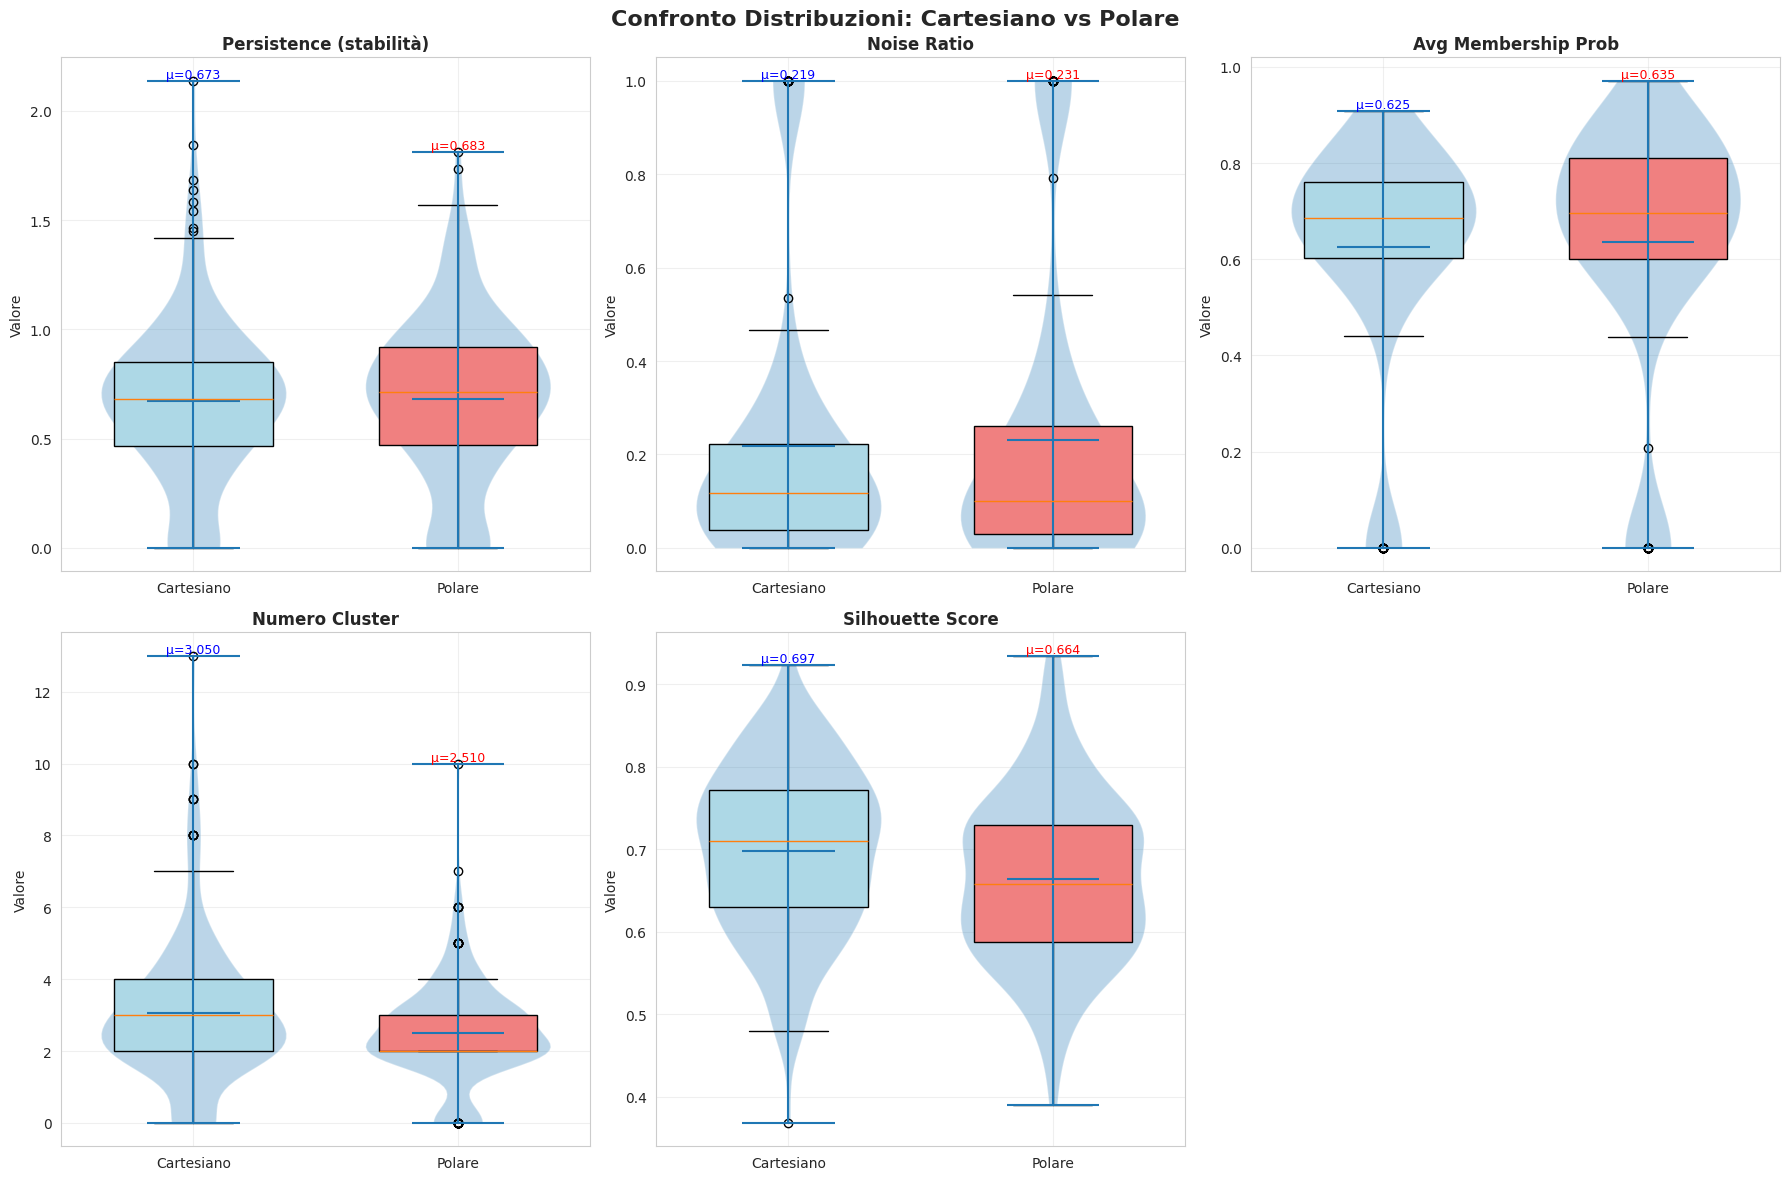

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Confronto Distribuzioni: Cartesiano vs Polare', fontsize=16, fontweight='bold')

metrics = [
    ('persistence', 'Persistence (stabilità)', True),
    ('noise_ratio', 'Noise Ratio', False),
    ('avg_prob', 'Avg Membership Prob', True),
    ('n_clusters', 'Numero Cluster', None),
    ('silhouette', 'Silhouette Score', True)
]

for idx, (metric, title, higher_is_better) in enumerate(metrics):
    if idx >= 5:
        break
    
    ax = axes[idx // 3, idx % 3]
    
    cart_col = f'cart_{metric}'
    polar_col = f'polar_{metric}'
    
    # Filtra valori invalidi per silhouette
    if metric == 'silhouette':
        valid_mask = (df_results[cart_col] > -1) & (df_results[polar_col] > -1)
        cart_data = df_results.loc[valid_mask, cart_col]
        polar_data = df_results.loc[valid_mask, polar_col]
    else:
        cart_data = df_results[cart_col]
        polar_data = df_results[polar_col]
    
    # Box plot affiancati
    positions = [1, 2]
    bp = ax.boxplot(
        [cart_data, polar_data],
        positions=positions,
        widths=0.6,
        patch_artist=True,
        labels=['Cartesiano', 'Polare']
    )
    
    # Colora i box
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    # Aggiungi violin plot semi-trasparente
    parts = ax.violinplot([cart_data, polar_data], positions=positions, widths=0.7, 
                          showmeans=True, showmedians=False)
    for pc in parts['bodies']:
        pc.set_alpha(0.3)
    
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Valore')
    ax.grid(True, alpha=0.3)
    
    # Aggiungi annotazione con media
    ax.text(1, cart_data.max(), f'μ={cart_data.mean():.3f}', 
            ha='center', va='bottom', fontsize=9, color='blue')
    ax.text(2, polar_data.max(), f'μ={polar_data.mean():.3f}', 
            ha='center', va='bottom', fontsize=9, color='red')

# Rimuovi subplot extra
if len(metrics) < 6:
    fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

## Distribuzione delle Differenze (Δ)

Visualizziamo la distribuzione delle differenze tra le due trasformazioni.  
Se la distribuzione è centrata su 0 → nessuna differenza reale.  
Se è spostata da 0 → una trasformazione è sistematicamente migliore.

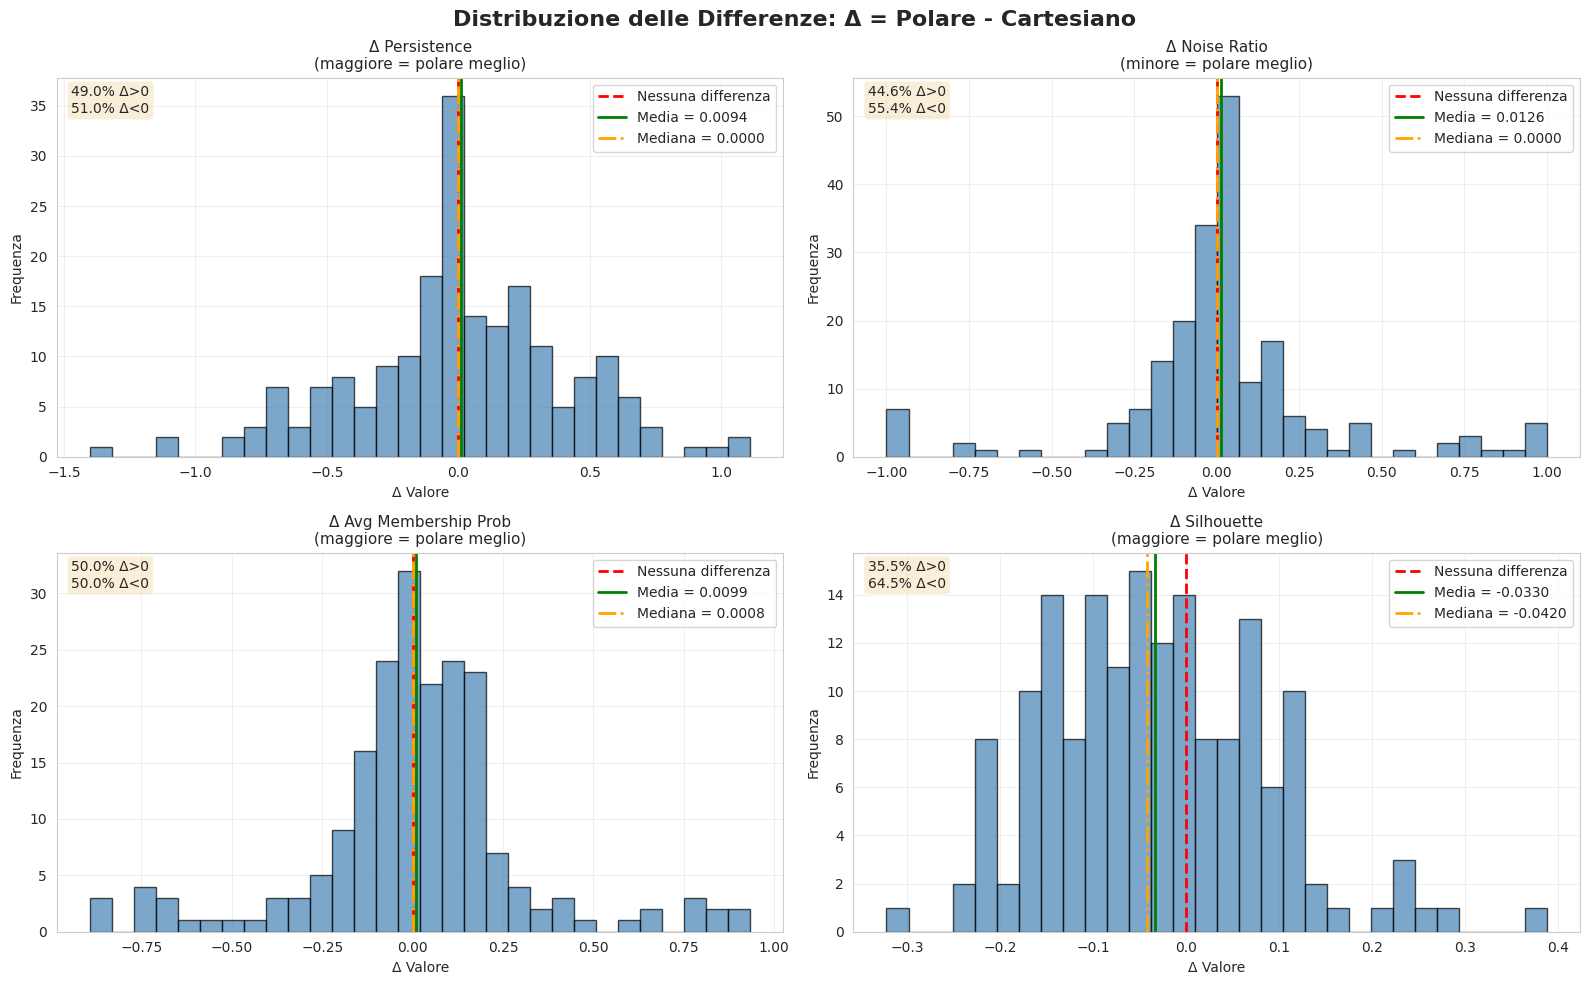

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribuzione delle Differenze: Δ = Polare - Cartesiano', fontsize=16, fontweight='bold')

delta_metrics = [
    ('delta_persistence', 'Δ Persistence', 'maggiore = polare meglio'),
    ('delta_noise_ratio', 'Δ Noise Ratio', 'minore = polare meglio'),
    ('delta_avg_prob', 'Δ Avg Membership Prob', 'maggiore = polare meglio'),
    ('delta_silhouette', 'Δ Silhouette', 'maggiore = polare meglio')
]

for idx, (delta_col, title, interpretation) in enumerate(delta_metrics):
    ax = axes[idx // 2, idx % 2]
    
    # Filtra valori validi
    if 'silhouette' in delta_col:
        valid_mask = (df_results['cart_silhouette'] > -1) & (df_results['polar_silhouette'] > -1)
        data = df_results.loc[valid_mask, delta_col]
    else:
        data = df_results[delta_col]
    
    # Istogramma
    ax.hist(data, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    
    # Linea verticale a 0
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Nessuna differenza')
    
    # Linea della media
    mean_val = data.mean()
    ax.axvline(x=mean_val, color='green', linestyle='-', linewidth=2, label=f'Media = {mean_val:.4f}')
    
    # Linea della mediana
    median_val = data.median()
    ax.axvline(x=median_val, color='orange', linestyle='-.', linewidth=2, label=f'Mediana = {median_val:.4f}')
    
    ax.set_xlabel('Δ Valore')
    ax.set_ylabel('Frequenza')
    ax.set_title(f'{title}\n({interpretation})', fontsize=11)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Aggiungi testo con percentuale da un lato
    n_positive = (data > 0).sum()
    pct_positive = n_positive / len(data) * 100
    ax.text(0.02, 0.98, f'{pct_positive:.1f}% Δ>0\n{100-pct_positive:.1f}% Δ<0', 
            transform=ax.transAxes, va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## Scatter Plot: Cartesiano vs Polare

Visualizziamo la correlazione tra le metriche delle due trasformazioni.  
Punti sopra la diagonale → Polare meglio  
Punti sotto la diagonale → Cartesiano meglio

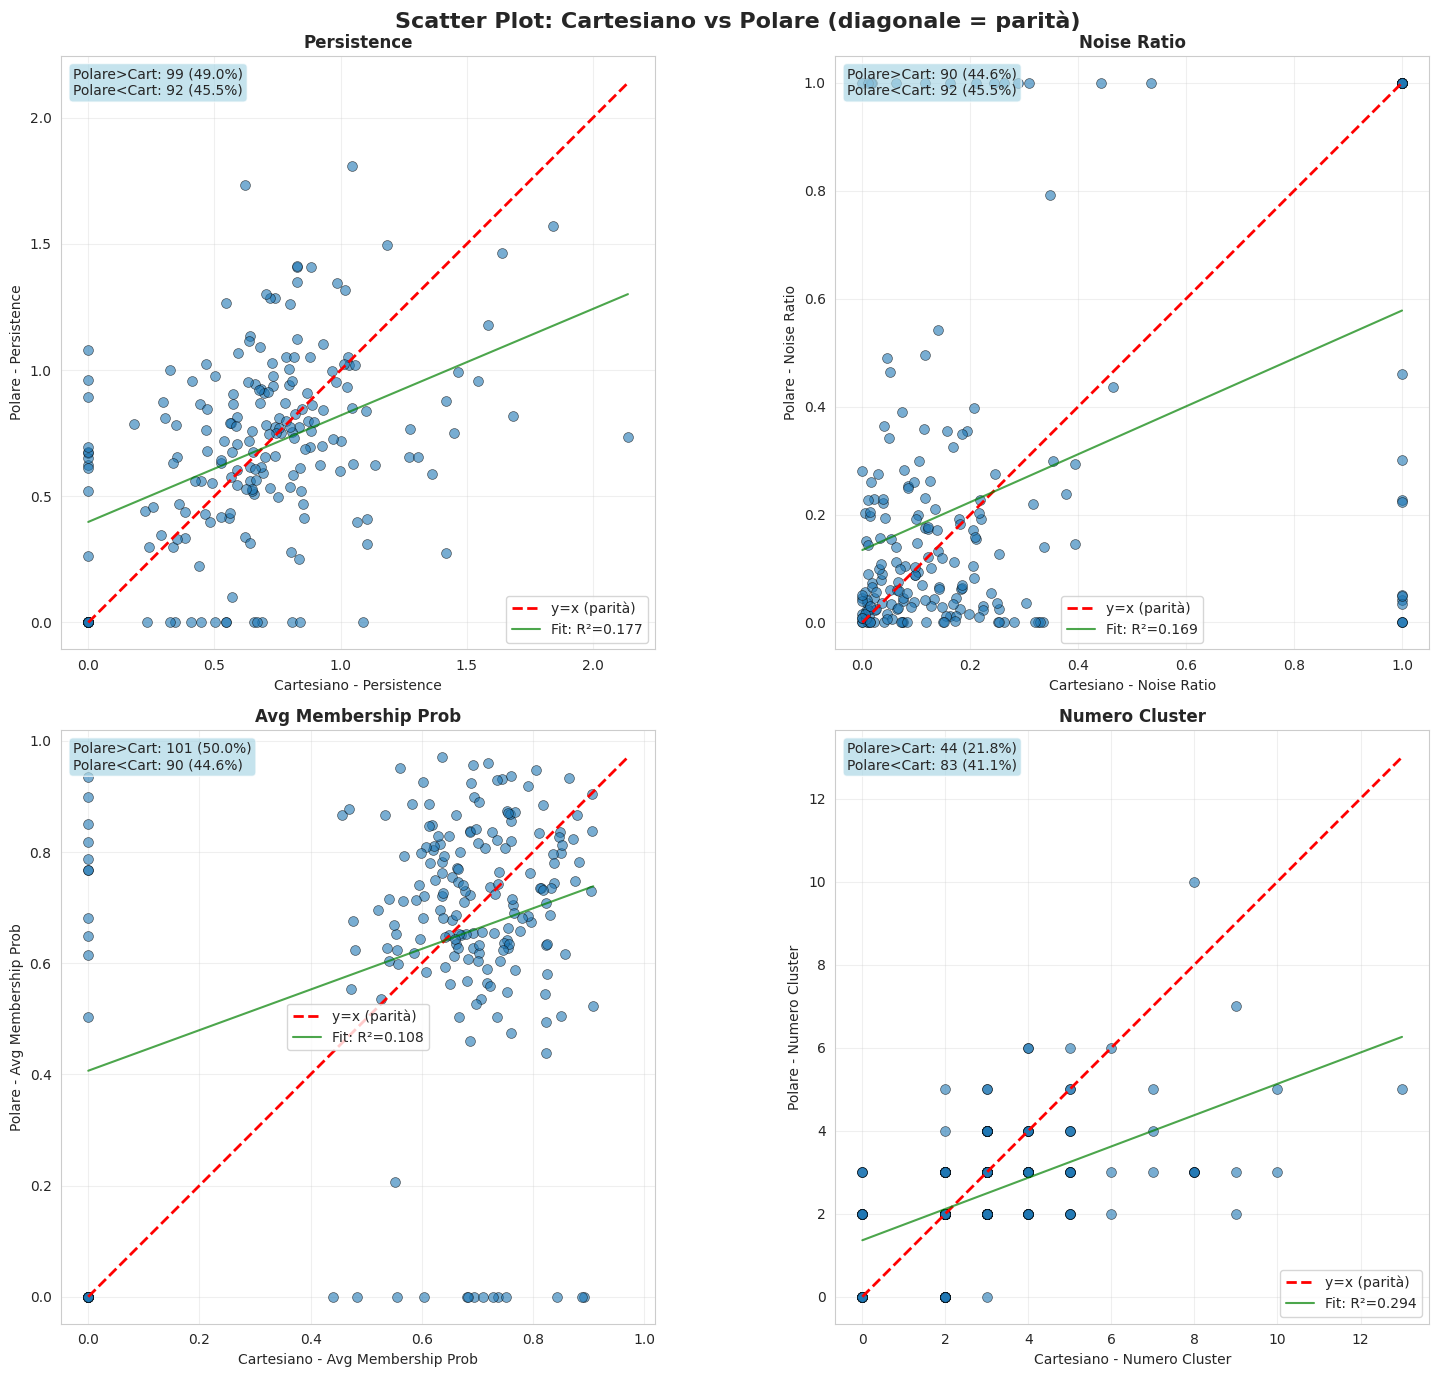

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Scatter Plot: Cartesiano vs Polare (diagonale = parità)', fontsize=16, fontweight='bold')

scatter_metrics = [
    ('persistence', 'Persistence'),
    ('noise_ratio', 'Noise Ratio'),
    ('avg_prob', 'Avg Membership Prob'),
    ('n_clusters', 'Numero Cluster')
]

for idx, (metric, title) in enumerate(scatter_metrics):
    ax = axes[idx // 2, idx % 2]
    
    cart_col = f'cart_{metric}'
    polar_col = f'polar_{metric}'
    
    x = df_results[cart_col]
    y = df_results[polar_col]
    
    # Scatter plot
    ax.scatter(x, y, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    
    # Linea diagonale (parità)
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y=x (parità)')
    
    # Regressione lineare
    from scipy.stats import linregress
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    line_x = np.array([x.min(), x.max()])
    line_y = slope * line_x + intercept
    ax.plot(line_x, line_y, 'g-', linewidth=1.5, alpha=0.7, 
            label=f'Fit: R²={r_value**2:.3f}')
    
    ax.set_xlabel(f'Cartesiano - {title}')
    ax.set_ylabel(f'Polare - {title}')
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')
    
    # Conta punti sopra/sotto diagonale
    above = (y > x).sum()
    below = (y < x).sum()
    total = len(x)
    ax.text(0.02, 0.98, f'Polare>Cart: {above} ({above/total*100:.1f}%)\nPolare<Cart: {below} ({below/total*100:.1f}%)', 
            transform=ax.transAxes, va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.show()

## Riepilogo Finale e Raccomandazione

Sintetizziamo tutti i risultati per dare una raccomandazione finale basata sui dati

In [48]:
# Crea tabella riassuntiva dei test
summary_df = pd.DataFrame(test_results)

print("="*80)
print("📊 TABELLA RIASSUNTIVA DEI TEST STATISTICI")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)

# Conta quante metriche mostrano significatività
n_significant = summary_df['is_significant'].sum()
n_total = len(summary_df)

print(f"\n\n{'='*80}")
print("🎯 RACCOMANDAZIONE FINALE")
print("="*80)

print(f"\nMetriche con differenza significativa (p<0.05): {n_significant}/{n_total}")

# Determina quale trasformazione è generalmente migliore
polar_wins = 0
cart_wins = 0

for _, row in summary_df.iterrows():
    if row['is_significant']:
        metric = row['metric']
        mean_delta = row['mean_delta']
        
        # Persistence, avg_prob, silhouette: maggiore = meglio
        if 'PERSISTENCE' in metric or 'PROBABILITY' in metric or 'SILHOUETTE' in metric:
            if mean_delta > 0:
                polar_wins += 1
            else:
                cart_wins += 1
        # Noise: minore = meglio
        elif 'NOISE' in metric:
            if mean_delta < 0:
                polar_wins += 1
            else:
                cart_wins += 1

print(f"\nMetriche dove POLARE è significativamente migliore: {polar_wins}")
print(f"Metriche dove CARTESIANO è significativamente migliore: {cart_wins}")

print("\n" + "-"*80)

if polar_wins > cart_wins:
    print("✅ RACCOMANDAZIONE: Usa la trasformazione POLARE")
    print(f"   La trasformazione polare è statisticamente superiore in {polar_wins} metriche chiave")
elif cart_wins > polar_wins:
    print("✅ RACCOMANDAZIONE: Usa la trasformazione CARTESIANA")
    print(f"   La trasformazione cartesiana è statisticamente superiore in {cart_wins} metriche chiave")
else:
    if n_significant == 0:
        print("⚠️  RACCOMANDAZIONE: NESSUNA DIFFERENZA SIGNIFICATIVA")
        print("   Le due trasformazioni producono risultati statisticamente equivalenti")
        print("   Scegli in base a preferenze implementative o interpretabilità")
    else:
        print("⚠️  RACCOMANDAZIONE: RISULTATI CONTRASTANTI")
        print("   Entrambe le trasformazioni hanno vantaggi in metriche diverse")
        print("   Prioritizza in base alla metrica più importante per il tuo caso d'uso:")
        print("   - Se priorità è STABILITÀ → guarda persistence")
        print("   - Se priorità è RIDURRE RUMORE → guarda noise_ratio")
        print("   - Se priorità è CONFIDENZA → guarda avg_membership_prob")

print("\n" + "="*80)

# Metriche più importanti per decisione
print("\n📌 METRICHE CHIAVE DA CONSIDERARE (in ordine di importanza):")
print("   1. PERSISTENCE: misura la stabilità e separazione dei cluster")
print("   2. NOISE RATIO: percentuale di dati non clusterizzati")
print("   3. AVG MEMBERSHIP PROB: confidenza nelle assegnazioni")
print("   4. SILHOUETTE: coesione vs separazione dei cluster")

print("\n" + "="*80)

📊 TABELLA RIASSUNTIVA DEI TEST STATISTICI
                         metric  mean_delta  median_delta  std_delta  p_ttest  p_wilcoxon  cohens_d  pct_polar_better  is_significant
PERSISTENCE (stabilità cluster)    0.009431      0.000000   0.409550 0.743791    0.545895  0.023028         49.009901           False
         NOISE RATIO (% rumore)    0.012561      0.000000   0.330416 0.589589    0.781395  0.038015         45.544554           False
     AVG MEMBERSHIP PROBABILITY    0.009909      0.000804   0.295026 0.633624    0.253796  0.033587         50.000000           False
               SILHOUETTE SCORE   -0.032974     -0.041956   0.116318 0.000349    0.000083 -0.283481         35.542169            True


🎯 RACCOMANDAZIONE FINALE

Metriche con differenza significativa (p<0.05): 1/4

Metriche dove POLARE è significativamente migliore: 0
Metriche dove CARTESIANO è significativamente migliore: 1

--------------------------------------------------------------------------------
✅ RACCOMANDAZ

## (Opzionale) Analisi di Robustezza con Bootstrap

Verifichiamo la stabilità dei risultati ripetendo l'analisi su sottocampioni casuali dei dataset

Bootstrap:   0%|          | 0/100 [00:00<?, ?it/s]

Bootstrap: 100%|██████████| 100/100 [00:00<00:00, 899.49it/s]


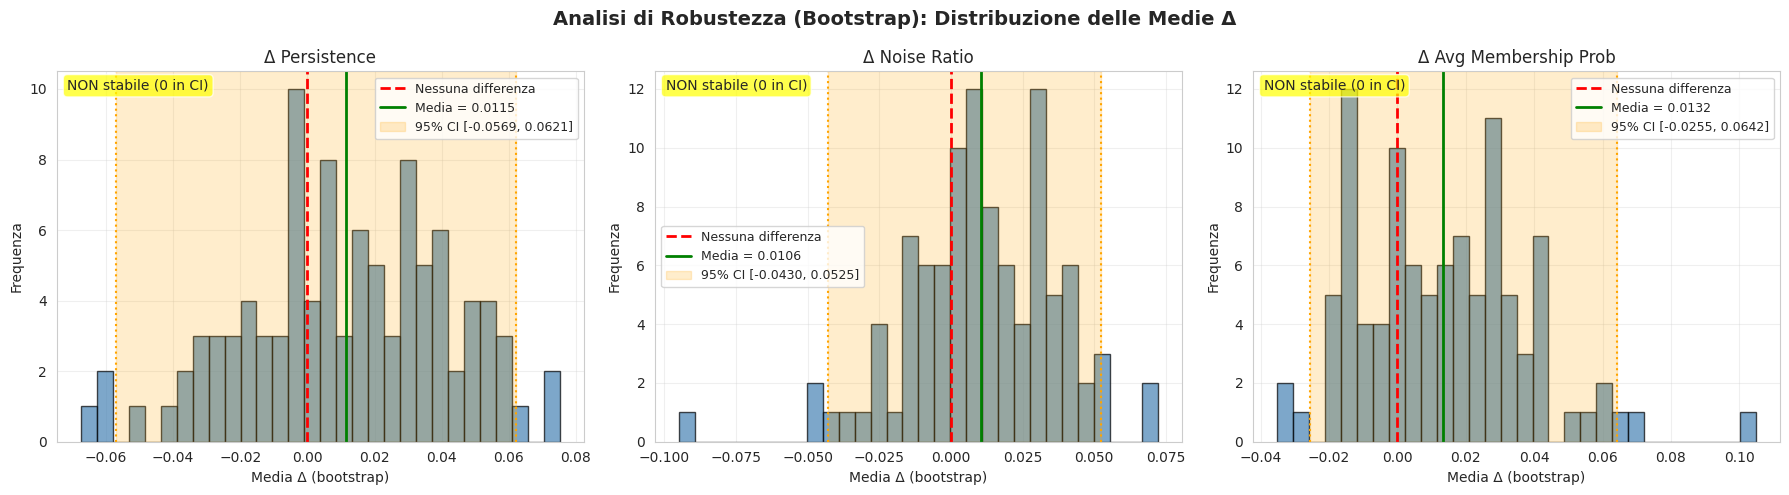


📊 ANALISI DI ROBUSTEZZA (Bootstrap):
Se l'intervallo di confidenza al 95% NON contiene 0 → risultato robusto e stabile
Se contiene 0 → risultato meno robusto, potrebbero esserci dataset outlier influenti


In [49]:
# Bootstrap per valutare robustezza dei risultati
# Utile se hai incertezza sulla stabilità delle conclusioni

N_BOOTSTRAP = 100  # numero di iterazioni bootstrap
SAMPLE_SIZE = int(len(df_results) * 0.8)  # usa 80% dei dati per ogni campione

bootstrap_results = {
    'persistence': [],
    'noise_ratio': [],
    'avg_prob': []
}

np.random.seed(42)

for i in tqdm(range(N_BOOTSTRAP), desc="Bootstrap"):
    # Campiona con replacement
    sample_indices = np.random.choice(len(df_results), size=SAMPLE_SIZE, replace=True)
    sample_df = df_results.iloc[sample_indices]
    
    # Calcola media delle differenze per ogni metrica
    bootstrap_results['persistence'].append(sample_df['delta_persistence'].mean())
    bootstrap_results['noise_ratio'].append(sample_df['delta_noise_ratio'].mean())
    bootstrap_results['avg_prob'].append(sample_df['delta_avg_prob'].mean())

# Visualizza distribuzioni bootstrap
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Analisi di Robustezza (Bootstrap): Distribuzione delle Medie Δ', fontsize=14, fontweight='bold')

for idx, (metric, title) in enumerate([
    ('persistence', 'Δ Persistence'),
    ('noise_ratio', 'Δ Noise Ratio'),
    ('avg_prob', 'Δ Avg Membership Prob')
]):
    ax = axes[idx]
    data = bootstrap_results[metric]
    
    ax.hist(data, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Nessuna differenza')
    ax.axvline(x=np.mean(data), color='green', linestyle='-', linewidth=2, label=f'Media = {np.mean(data):.4f}')
    
    # Intervallo di confidenza 95%
    ci_lower = np.percentile(data, 2.5)
    ci_upper = np.percentile(data, 97.5)
    ax.axvline(x=ci_lower, color='orange', linestyle=':', linewidth=1.5)
    ax.axvline(x=ci_upper, color='orange', linestyle=':', linewidth=1.5)
    ax.axvspan(ci_lower, ci_upper, alpha=0.2, color='orange', label=f'95% CI [{ci_lower:.4f}, {ci_upper:.4f}]')
    
    ax.set_xlabel('Media Δ (bootstrap)')
    ax.set_ylabel('Frequenza')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Verifica se 0 è nell'intervallo di confidenza
    contains_zero = ci_lower <= 0 <= ci_upper
    stability_text = "NON stabile (0 in CI)" if contains_zero else "STABILE (0 fuori CI)"
    ax.text(0.02, 0.98, stability_text, 
            transform=ax.transAxes, va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='yellow' if contains_zero else 'lightgreen', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n📊 ANALISI DI ROBUSTEZZA (Bootstrap):")
print("Se l'intervallo di confidenza al 95% NON contiene 0 → risultato robusto e stabile")
print("Se contiene 0 → risultato meno robusto, potrebbero esserci dataset outlier influenti")

## Salvataggio Risultati

Salviamo i risultati per analisi future o per reportistica

In [50]:
# Salva risultati in CSV
output_path = Path('../data/clustering_comparison_results.csv')
df_results.to_csv(output_path, index=False)
print(f"✅ Risultati salvati in: {output_path}")

# Salva anche il riepilogo dei test
summary_path = Path('../data/clustering_statistical_tests.csv')
summary_df.to_csv(summary_path, index=False)
print(f"✅ Riepilogo test statistici salvato in: {summary_path}")

✅ Risultati salvati in: ../data/clustering_comparison_results.csv
✅ Riepilogo test statistici salvato in: ../data/clustering_statistical_tests.csv
